# Determination of realistic parameters


In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Heat exchanger U and As

secundair netwerk verwarming flow max: 700 l/h -> 0.194 l/s\
warmwater capaciteit tap: 9 l/min -> 0.15 l/s

31 kW is het vermogen dat warmtewissellaar kan leveren.\
gecheckt door dT * cp * mdot = 50 * 4.18e3 * 0.15 = 31 kW aan de secundaire zijde

30 * 4.18e3 * m_prim = 31 kW \
m_prim = 31e3 / (4.18e3 * 30) = 0.247 kg/s aan primaire zijde, dit is hoeveel hij nodig heeft om aan de andere kant de max hoeveelheid water te verwarmen. 
Echter hij moet altijd het water verwarmen tot 60 graden. 

In [43]:
# Determination of Heat Exhanger parameters 
c_water = 4.18e3 
U = 4000  # Overall heat transfer coefficient [W/m2K] obtained via site https://www.engineeringtoolbox.com/heat-transfer-coefficients-exchangers-d_450.html

# Qdot = U * As * F * delta_T_mean
# For tapwater heater
Th_in = 65
Th_out = 35
Tc_in = 10
Tc_out = 60
Qdot = 31e3 # W
F = 0.95

delta1 = Th_in - Tc_out
delta2 = Th_out - Tc_in

if delta1 == delta2: 
    dTmean = delta1
else:
    dTmean = (delta1 - delta2) / \
                np.log(delta1/delta2)

UAs = Qdot / (dTmean * F)
print(f'Tapwater: UAs = {UAs} W/K, U = 4000 W/m2K => As = {UAs/4000} m2')
print(f'dTlm = {dTmean} K')

# Higher UAs needed for tapwater requires less flow for the space heating system. 
# But now the problem is that the 

Tapwater: UAs = 2625.925015024058 W/K, U = 4000 W/m2K => As = 0.6564812537560145 m2
Spaceheating: transferred heat with tapwater parameters 30999.999999999996
dTlm = 12.426698691192238 K


In [34]:
# lets assume that we want a 50 K temperature difference on the secundary side. And we scale the amount of water to the max water. And we request 20 kW
Q_demand = 50 * 4.18e3 * 20/31*0.15
31/(30*4.18)

0.24720893141945774

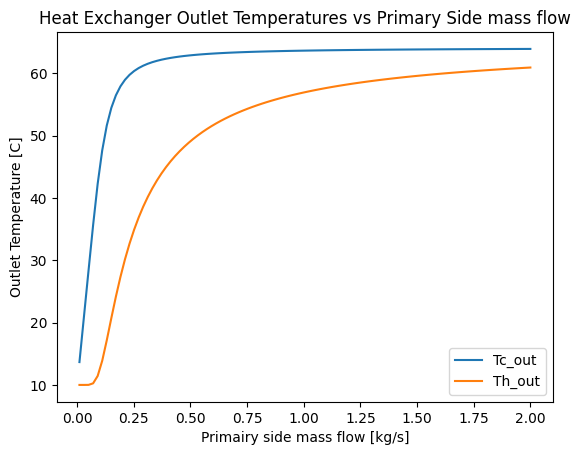

In [44]:
def NTU_method(mflow_h,mflow_c,Th_in,Tc_in):
 
    F = 0.95

    # Heat capacity rates
    Cc = mflow_c * c_water
    Ch = mflow_h * c_water         

    Cmin = min(Cc, Ch)
    Cmax = max(Cc, Ch)
    Cr = Cmin / Cmax

    NTU = (UAs) / Cmin

    # Effectiveness calculation for counterflow heat exchanger
    if Cr != 1:
        epsilon = (1 - np.exp(-NTU * (1 - Cr))) / (1 - Cr * np.exp(-NTU * (1 - Cr)))
    else:
        epsilon = NTU / (1 + NTU)

    Q = epsilon * Cmin * (Th_in - Tc_in)
    # print(Q)

    Tc_out = Tc_in + Q / Cc
    Th_out = Th_in - Q / Ch
    
    return Tc_out, Th_out

mflowh_in = np.linspace(0.01,2,100)
mflow_c = 0.15 # kg/s
Th_in = 65
Tc_in = 10

Tc_out_array = []
Th_out_array = []   
for mflowh in mflowh_in:
    Tc_out, Th_out = NTU_method(mflowh, mflow_c, Th_in, Tc_in)
    Tc_out_array.append(Tc_out)
    Th_out_array.append(Th_out)

plt.plot(mflowh_in, Tc_out_array, label='Tc_out')
plt.plot(mflowh_in, Th_out_array, label='Th_out')
plt.xlabel('Primairy side mass flow [kg/s]')
plt.ylabel('Outlet Temperature [C]')
plt.title('Heat Exchanger Outlet Temperatures vs Primary Side mass flow')
plt.legend()
plt.show()

In [46]:
mflow_h = 0.249
mflow_c = 0.15
Th_in = 65 
Tc_in = 10

Tc_out, Th_out = NTU_method(mflow_h,mflow_c, Th_in, Tc_in)
print(f'Tc_out = {Tc_out}, Th_out = {Th_out}')

Tc_out = 60.33145500059857, Th_out = 34.67984638518159


# Heat demand profile
Alleen maar tap water in zomer!!

Op site Eneco staat 6.6 GJ voor warm tapwater gemiddeld per jaar voor een huishouden.

6.6e9/365 = 18 MJ per dag\
18e6/30e3 = 600 sec kan je op max vermogen douchen. 

Gaan voor een stapsgewijze opbouw alsof iemand aan het douchen is.\
Dus doen 2 min op 20 kW, 2 min op 25 kW en 6 min op 30 kW.



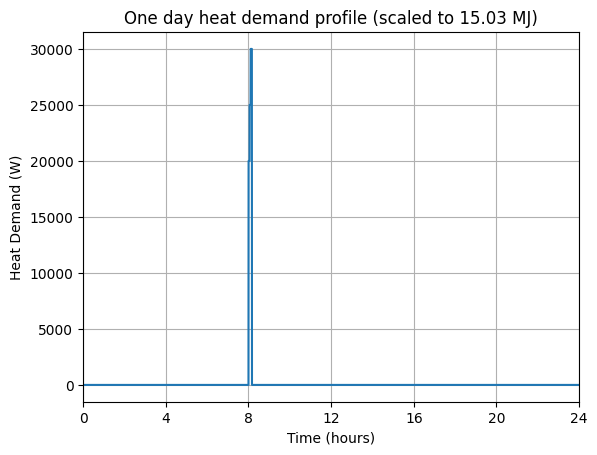

In [ ]:
# Tijdas
t = np.linspace(0, 24*3600, 24*3600)

# Stapintervallen
t1_start, t1_end = 8*3600, 8.05*3600
t2_start, t2_end = t1_end, 8.1*3600
t3_start, t3_end = t2_end, 8.164*3600

# Hoogtes van de stappen
h1, h2, h3 = 1.0, 2.0, 3.0

# Signaal (overal nul)
y = np.zeros_like(t)

# Drie blockgolven naast elkaar
y[(t >= t1_start) & (t < t1_end)] = 20e3
y[(t >= t2_start) & (t < t2_end)] = 25e3
y[(t >= t3_start) & (t < t3_end)] = 30e3


plt.plot(t, y)
plt.title(f"One day heat demand profile (scaled to {round(np.trapz(y, t)/1e6,3)} MJ)")
plt.xlabel("Time (hours)")
plt.ylabel("Heat Demand (W)")

ax = plt.gca()
ax.set_xlim(0, 24 * 3600)  # limits in seconds
ticks_seconds = np.arange(0, 25, 4) * 3600
ax.set_xticks(ticks_seconds)
ax.set_xticklabels([f'{int(h)}' for h in np.arange(0, 25, 4)])

plt.grid()
plt.show()

# Pressure relation HEX

In [17]:
# 31 kW = c_p * Qprim * dT_prim_tap, dT_prim_tap = 65 -> 35 degrees
# dp_hex = rho * Kp_dp * mflow ** 2
mflow_prim = 31e3 / (4.18e3 * 30)
dp_hex = 35e3 # Pa according to brochure for primary system
rho = 1000

Kp_dp = dp_hex / (rho * mflow_prim **2)

print(f'Kp_dp {Kp_dp}, mflow {mflow_prim}')

Kp_dp 572.7165452653486, mflow 0.24720893141945774


# Pressure pipe with data Rutger
Checking implementation of Darcy Weisbach

# Equal percentage valve

~~Robbert said that open Kv is 0.1, which I probably assume to be [$m^{3}/h/\sqrt{bar}$]. Which would mean that Kvs 0.1/3.6 = 0.028 [$kg/s/\sqrt{bar}$] \
And Kv0 = 0.028/50 = 5.5e-5\
However, the value of Kv0 is larger than the actual leak. But this requires the implementation of a more precise relation for h around the small area of the valve.~~

I adjusted the values of the Kv to the values obtained from fitting Rutgers data to the network. With a pump of 60kPa, not 50kPa as it wasn't strong enough to provide the requested water flow. Also with a Re = 10e3. Changing the Re effects the pressure change a lot over the pipe lines meaning they also influence the seize of the Kv. As for the upperbranch the amount of water that was flowing through is 0.1748 kg/s = 629 kg/h. A perfectly functioning heat exchanger has a mass flow of 0.24 kg/s = 864 kg/h (based on the values given in the brochure). For the valve on the first level the mass flow is: 0.02717314 kg/s = 97 kg/h. Therefore I also didn't want this to be the Kv0. So I scaled it to a seize where the valve is h= 0.2ish.

These are the calculated Kv values for fitting Rutger's data. Out of simplicity I choose Kvs = 0.003 in this way the lowest values are still in a somewhat controllable range and it indicitates that the valve is not completely open. 

Calculated Kv values for valves: [0.00011312 0.00011714 0.00012139 0.00012587 0.00013061 0.00086279
 0.0001231  0.00013042 0.00013838 0.00014707 0.00015658 0.00016703
 0.0001786  0.00019149 0.00020603 0.00022267 0.00024216 0.00026573
 0.00029559 0.00025407 0.00042842 0.00057599 0.00291382]

$\Delta p = (\frac{\dot{V}}{K_v})^2  \frac{\rho}{\rho_{\textbf{ref}}} = (\frac{\dot{m}}{\rho K_v})^2$, page 25 phd, but in the simulation I just do: $(\frac{\dot{m}}{K_v})^2$

Valve authority should be between 0.3 - 0.5. page 114

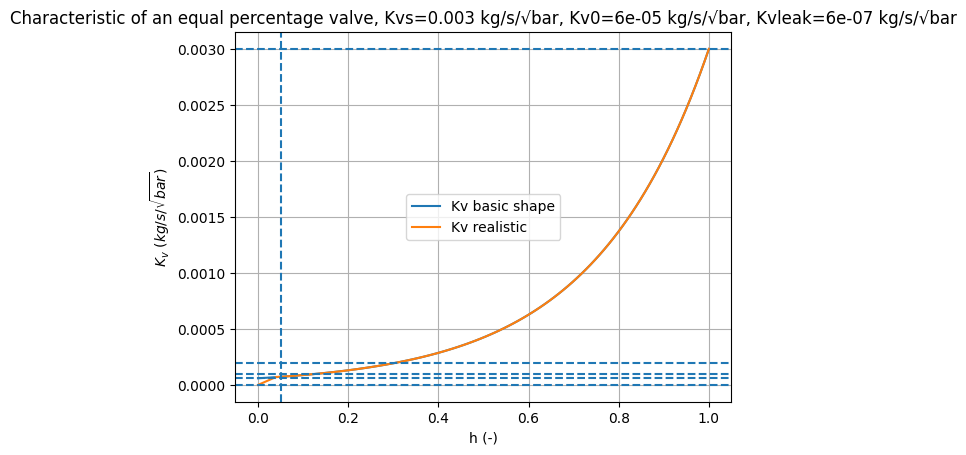

In [ ]:
# functions return Kv/Kvs

def Kv_ideal_func(h, Kvs):
    Kv0 = Kvs/50
    return (Kvs / Kv0) ** (h-1) * Kvs

def Kvleak_func(h,Kvs):
    Kvleak = Kvs/5000
    return (Kvs/Kvleak) ** (h-1)*Kvleak

def Kv_real_func(h,Kvs,h_star):
    Kv0 = Kvs/50
    Kvleak = Kvs/5000

    if h < h_star:
        Kv = Kvleak + h*(Kv_ideal_func(0.1,Kvs) - Kvleak)/h_star
        # Kv = Kvleak_func(h, Kvs/100)
    else:
        Kv = (Kvs/Kv0) ** (h-1)* Kvs
    return Kv

h_array = np.linspace(0,1,100)
Kvs = 0.003
h_star = 0.05


Kv_ideal_array = []
Kv_real_array = []
for h in h_array:
    Kv_ideal_array.append(Kv_ideal_func(h,Kvs))
    Kv_real_array.append(Kv_real_func(h,Kvs,h_star))

# In phd thesis he says that the typical ratio between Kvs/Kv0 is between 25 - 50 (p26) Higher ratio means beter control flow. 

plt.figure()

plt.plot(h_array, Kv_ideal_array, label='Kv basic shape')
plt.plot(h_array, Kv_real_array, label='Kv realistic')

plt.axhline(Kvs/5000, linestyle='--')
plt.axhline(Kvs/50, linestyle='--')
plt.axhline(Kvs, linestyle='--')
plt.axhline(0.0001, linestyle='--')
plt.axhline(0.0002, linestyle='--')


plt.axvline(h_star, linestyle='--')

plt.xlabel('h (-)')
plt.ylabel(r'$K_v$ $(kg/s/\sqrt{bar}$)')
plt.title(f"Characteristic of an equal percentage valve, Kvs={Kvs} kg/s/√bar, Kv0={Kvs/50} kg/s/√bar, Kvleak={Kvs/5000} kg/s/√bar")

plt.legend()
plt.grid()
plt.show()


Text(0.5, 1.0, 'Realistic pressure drop with mflow 0.02513274122871835 kg/s')

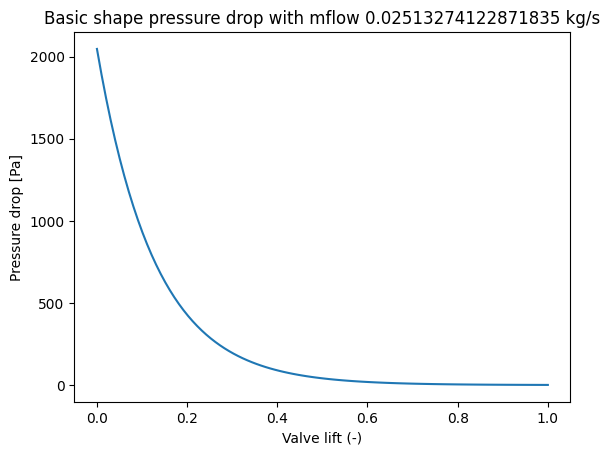

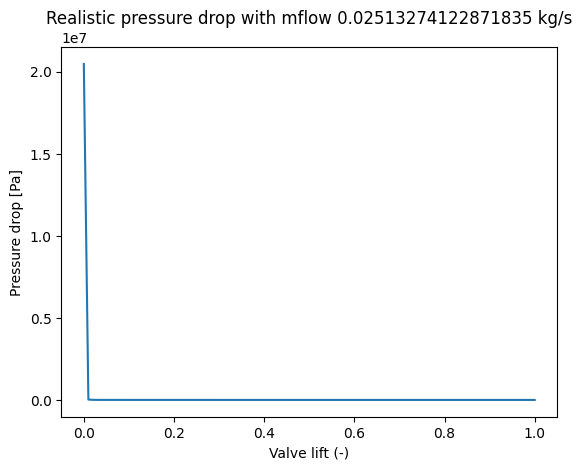

In [28]:
# mflow = 0.24 #kg/s
mflow = 0.02 * np.pi * 1000 * 0.02**2
Kvs = 0.1/3.6
h_star = 0.05

dp_array_ideal = np.zeros(100)
dp_array_real = np.zeros(100)

for k in range(len(h_array)):   
    Kv_ideal = Kv_ideal_func(h_array[k],Kvs)
    Kv_real = Kv_real_func(h_array[k],Kvs, h_star)
    dp_array_ideal[k] = (mflow/(Kv_ideal))**2
    dp_array_real[k] = (mflow/(Kv_real))**2

plt.figure()
plt.plot(h_array,dp_array_ideal)
plt.xlabel("Valve lift (-)")
plt.ylabel("Pressure drop [Pa]")
plt.title(f"Basic shape pressure drop with mflow {mflow} kg/s")

plt.figure()
plt.plot(h_array, dp_array_real)
plt.xlabel("Valve lift (-)")
plt.ylabel("Pressure drop [Pa]")
plt.title(f"Realistic pressure drop with mflow {mflow} kg/s")
# plt.show()

Text(0, 0.5, 'Mass flow (kg/s)')

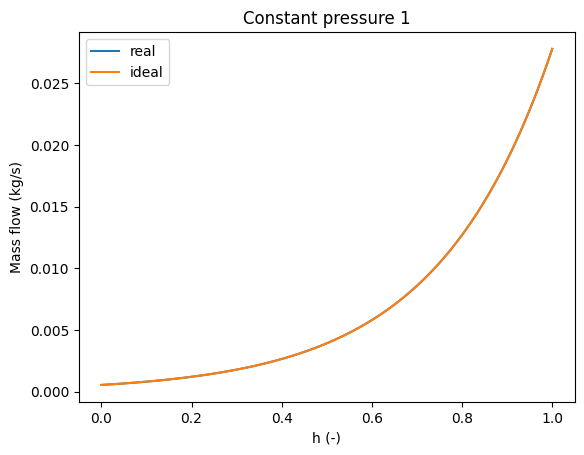

In [29]:
dp = 1
mflow_array_real = np.zeros(100)
mflow_array_ideal = np.zeros(100)

Kvs = 0.1/3.6
h_star = 0.05

for k in range(len(h_array)):
    
    Kv_real = Kv_real_func(h_array[k],Kvs, h_star)
    Kv_ideal = Kv_ideal_func(h_array[k], Kvs)
    mflow_array_real[k] = Kv_real * np.sqrt(dp)
    mflow_array_ideal[k] = Kv_ideal * np.sqrt(dp)

plt.plot(h_array, mflow_array_ideal, label = 'real')
plt.plot(h_array, mflow_array_ideal, label = 'ideal')
plt.legend()
plt.title(f'Constant pressure: {dp} Pa')
plt.xlabel('h (-)')
plt.ylabel('Mass flow (kg/s)')


# Pump 

v_max = 1 m/s \
mdot = pi * 0.02 ** 2 * 1 * 1000 = 0.6 pi 


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[-25330.29591058  -7957.74715459  50000.        ]


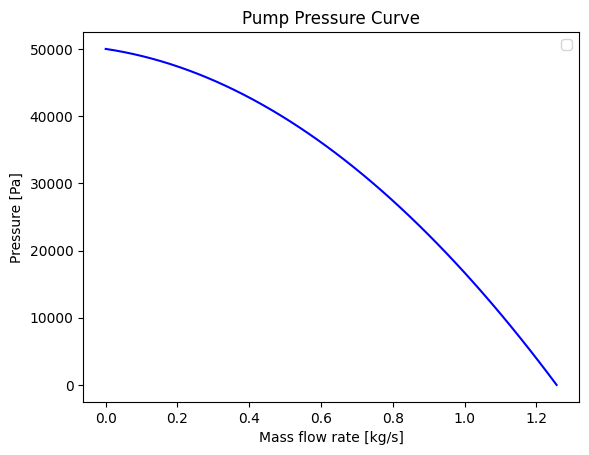

In [44]:
# Measurement data points

mflow_max = 0.02**2 * 1 * 1000 * np.pi  # kg/s
dp_data = np.array([50e3, 20e3, 0])  # Pa
mflow_data = np.array([0, 0.3*np.pi, mflow_max])  # kg/s

# Fit quadratic curve to data: dp = a*mflow^2 + b*mflow + c
coefficients = np.polyfit(mflow_data, dp_data, 2)
a, b, c = coefficients

print(coefficients)

# Update pump_curve function with fitted coefficients
def pump_curve(mflow):
    dp = a * mflow**2 + b * mflow + c
    return dp

# Verify fit
mflow_test = np.linspace(0, mflow_max, 50)
dp_fit = [pump_curve(m) for m in mflow_test]

plt.figure()
# plt.plot(mflow_data, dp_data, 'ro', label='Measurement data')
plt.plot(mflow_test, dp_fit, 'b-')
plt.xlabel('Mass flow rate [kg/s]')
plt.ylabel('Pressure [Pa]')
plt.title('Pump Pressure Curve')
plt.legend()
plt.show()



# Compare Rutgers data with simulation, checking pressure loss over pipes

### Checking Darcy Weisbach 

In [ ]:
# Determination of the Reynolds number based on the Darcy-Weisbach equation
L  = 3  # m
D = 0.04 # m
v = 0.87 # m/s
dp = 803.5  # Pa

rho = 1000 # kg/m3
epsilon = 0.045e-3 # m

# Re = rho * v * D / mu
mu = 0.001 # Pa.s
Re_check = rho * v * D / mu
f_check = (1 / (-1.8 * np.log10( ((epsilon/D)/3.7)**1.11 + 6.9/Re_check)))**2
dp = f_check * L * rho * v**2 / (2 * D)
print(f'f_check = {f_check}, Re check = {Re_check}, dp check = {dp} Pa')

# Solve Haaland equation for Re
f = (2 * dp * D) / (L * rho * v**2)
e_term = (epsilon/D/3.7)**1.11
Re = 6.9 / (10**(-1/(1.8*np.sqrt(f))) - e_term)

print(f' f = {f}, dp = {dp} Pa, Re = {Re}, epsilon/D = {epsilon/D}')

f_check = 0.02532897889417203, Re check = 34800.0, dp check = 718.9314046874554 Pa
 f = 0.025328978894172027, dp = 718.9314046874554 Pa, Re = 34799.99999999992, epsilon/D = 0.0011250000000000001


#### Difference in turbulent and laminair flow

In [70]:
def dp_tur(L,D,mflow):

    # Re = rho * v * D / mu
    mu = 0.001 # Pa.s for 50 degrees
    epsilon = 0.045e-3
    rho = 1000

    v = mflow / (rho * np.pi * (D/2)**2)
    Re = rho * v * D / mu

    # Re = 10e3

    # print(f'Re {Re}, v {v}')
# 
    log_term = ((epsilon/D)/3.7)**1.11 + (6.9/Re)
    f = (1 / (-1.8 * np.log10(log_term)))**2

    return f * (L / D) * (rho * v**2 / 2)

def dp_lam(L,D,mflow):

    # Re = rho * v * D / mu
    mu = 0.001 # Pa.s for 50 degrees
    rho = 1000

    v = mflow / (rho * np.pi * (D/2)**2)
    Re = rho * v * D / mu

    f = 64/Re
    # print(f)

    return f * (L / D) * (rho * v**2 / 2)

#### Validating the found velocities in a pressure loop

In [71]:
# velocities
vgem1 = 0.8738
vgem2 = 0.8522113
v_hex = vgem1 - vgem2

# Pipe diameters
D = 0.04
D_hex_pipes = 0.02

mflow1 = np.pi * (D/2) **2 * vgem1 * rho
mflow_hex = np.pi * (D/2) ** 2 * v_hex * rho

# Hex pressure calc
Kp_dp = 611
dp_hex = Kp_dp * 1000 * mflow_hex ** 2

dp_meas = 803
m_hex_loop =  dp_tur(3,D_hex_pipes,mflow_hex)
return_pump = dp_tur(3,D,vgem1*np.pi*rho*(D/2)**2)


dp_tot = (dp_hex +  # pressure drop over HEX, where the pipes connected to the nodes are not taken into account
            dp_meas + # measured pressure drop over first pipe of 3 m
            m_hex_loop + # pressure dorp over 3m of DN40 conencted to the HEX loop
            return_pump) # pressure drop over pipe line connected to return network and the pump pipe.

print(f'{dp_tot}: total dp ')
print(f'{dp_hex}: hex dp')
print(f'{m_hex_loop}: 3m hex loop ')
print(f'{return_pump}: 2 m return + pump pipe')
print(f' \n')
print(f'{mflow_hex} mflow_hex ')
print(f'{mflow1} mflow vgem1')

# stel dat de hex flow geleverd is in 1 minuut, terwijl het gemiddlede van een uur is
mflow_hex_1min = mflow_hex*60
Tc_out, Th_out = NTU_method(mflow_hex_1min) # Th_in = 65, Tc_in = 10
print(f'Tc_out = {Tc_out}, Th_out = {Th_out}')

2008.1625996580874: total dp 
449.6907154402365: hex dp
30.72852791082683: 3m hex loop 
724.7433563070239: 2 m return + pump pipe
 

0.027129160528221605 mflow_hex 
1.0980494642827046 mflow vgem1
Tc_out = 57.454884945975756, Th_out = 60.62694863921333


###  Druk verval leidingen Rutger
Aanname van Rutger van 5kPa klopt niet. Het is veel meer druk verlies.

In [56]:
import os
import pandas as pd

def dp_fric(L,D,v,Re):
    f = (1 / (-1.8 * np.log10( ((epsilon/D)/3.7)**1.11 + 6.9/Re)))**2
    # print(f)
    return f * (L / D) * (rho * v**2 / 2), f

cwd = os.getcwd()
average_v_file = os.path.join(cwd, 'data', 'data_23floors_Rutger.csv')
average_v = pd.read_csv(average_v_file)['average v'].values

dp_tot = 0
for i in range(23):
    if i<6:
        D = 0.04
    elif 6<= i <19:
        D = 0.032
    else:
        D = 0.025
    v = average_v[i]
    mflow = v * np.pi * (D/2)**2 * 1000
    dp_pipe, f = dp_fric(3,D,v, 10e3)
    print(f'mflow {mflow}, dp_pipe {dp_pipe} Pa, friction factor {f}, velocity {v} m/s, diameter {D} m')

    dp_tot += dp_pipe

print(f'{dp_tot} Pa total pressure drop over 23 pipes, and only for going up')

mflow 1.0980934465798549, dp_pipe 926.2274852604047 Pa, friction factor 0.03234651711636037, velocity 0.873835 m/s, diameter 0.04 m
mflow 1.070920303754483, dp_pipe 880.9542801270511 Pa, friction factor 0.03234651711636037, velocity 0.8522113 m/s, diameter 0.04 m
mflow 1.0432174884077159, dp_pipe 835.9663241120228 Pa, friction factor 0.03234651711636037, velocity 0.8301661 m/s, diameter 0.04 m
mflow 1.0149488093921841, dp_pipe 791.2748127348308 Pa, friction factor 0.03234651711636037, velocity 0.8076706 m/s, diameter 0.04 m
mflow 0.9860735516670973, dp_pipe 746.8917900892546 Pa, friction factor 0.03234651711636037, velocity 0.7846924 m/s, diameter 0.04 m
mflow 0.9565455966523008, dp_pipe 702.8302066100049 Pa, friction factor 0.03234651711636037, velocity 0.7611948 m/s, diameter 0.04 m
mflow 0.7958044050624884, dp_pipe 1502.3214958651229 Pa, friction factor 0.03273321017587358, velocity 0.9895016 m/s, diameter 0.032 m
mflow 0.7691739937308543, dp_pipe 1403.4578947188907 Pa, friction fac

In [58]:
mflow_test = 0.33 #kg/s
L_test = 3
D_test = 0.04
v_test = mflow_test / (1000 * np.pi * (D_test/2)**2)
dp, f = dp_fric(L_test,D_test,v_test,10e3)
dp

83.65019249109714